# Assignment #3 - Embeddings

<font color="red"> <b> Due: Apr 3rd (Friday) </b> </font>

<font color="blue"> Abeoseh Flemister </font>

Read in necessary packages and define helper functions.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.datasets import imdb # IMDB dataset is included in Keras

from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.layers import Embedding, LSTM
from tensorflow.keras.utils import to_categorical          # Converts a class vector (integers) to binary class matrix.
from tensorflow.keras import regularizers

print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
import random

TF version: 2.20.0


`plot_learning` will allow me to plot the loss and accuracy for the validation and training dataset.

In [87]:
def plot_learning(history):
    tgts = ['loss', 'accuracy']
    vtgts = ['val_loss', 'val_accuracy']

    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
      plt.subplot(1,2, i+1)
      plt.plot(history.history[tgt], label=tgt)
      plt.plot(history.history[val_tgt], label=val_tgt)
      plt.xlabel('Epoch')
      #plt.ylabel(ylab)
      plt.legend()
      plt.title(f"Training and validation {tgt}")

# Introduction
The goal of this assignment is to practice learning how embeddings and RNN work for NLP tasks and how to leverage the pretrained embeddings. I am using the IMDB dataset of 25,000 movies reviews, classed as being either positive or negative sentiment. 


My goal is to create a bidirectional GRU which leverages pretrained GloVe embeddings which classify movie sentiment as being either positive or negaitve. The pretrained embeddings will allow me to reduce training time while conserving performance. 

# Data

I am reusing **IMDB dataset** from keras.

[Refer to this link for better understanding](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data)


In [2]:
max_features = 20000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

Padding the sequences so they are all 100 tokens long.

As we can see, before padding, the sequences in the testing and training dataset are all different lengths

In [69]:
for i in range(len(x_train)):
    if i < 5:
        print(f"len of seq {i} in x_train: {len(x_train[i])}") 
        print(f"len of seq {i} in x_test: {len(x_test[i])}")
        print("-"*30) 
    else:
        break

len of seq 0 in x_train: 218
len of seq 0 in x_test: 68
------------------------------
len of seq 1 in x_train: 189
len of seq 1 in x_test: 260
------------------------------
len of seq 2 in x_train: 141
len of seq 2 in x_test: 603
------------------------------
len of seq 3 in x_train: 550
len of seq 3 in x_test: 181
------------------------------
len of seq 4 in x_train: 147
len of seq 4 in x_test: 108
------------------------------


In [3]:
from keras.utils import pad_sequences
maxlen = 100
x_train = pad_sequences(x_train, maxlen)
x_test = pad_sequences(x_test, maxlen)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (25000, 100)
x_test shape: (25000, 100)


After padding by adding the 0 token, all the sequences are the same length.

In [75]:
for i in range(len(x_train)):
    if i < 5:
        print(f"len of seq {i} in x_train: {len(x_train[i])}") 
        print(f"len of seq {i} in x_test: {len(x_test[i])}")
        print("-"*30) 
    else:
        break

len of seq 0 in x_train: 100
len of seq 0 in x_test: 100
------------------------------
len of seq 1 in x_train: 100
len of seq 1 in x_test: 100
------------------------------
len of seq 2 in x_train: 100
len of seq 2 in x_test: 100
------------------------------
len of seq 3 in x_train: 100
len of seq 3 in x_test: 100
------------------------------
len of seq 4 in x_train: 100
len of seq 4 in x_test: 100
------------------------------


I split the **test** dataset in half so the size of the test and validation dataset are both 12,500. This allows me to be able to perform training, validation, and testing.

In [4]:
valid_indicies = random.sample(range(0, len(x_test)-1), len(x_test)//2)

x_valid = x_test[valid_indicies]
y_valid = y_test[valid_indicies]

x_test = np.delete(x_test, valid_indicies, axis = 0)
y_test = np.delete(y_test, valid_indicies)

# Method

## Word Embeddings

Crucially, when you encode something via one-hot encoding, you’re making a feature- engineering decision. You’re injecting into your model a fundamental assumption about the structure of your feature space. That assumption is that the different tokens you’re encoding are all independent from each other: indeed, one-hot vectors are all orthogonal to one another. And in the case of words, that assumption is clearly wrong. Words form a structured space: they share information with each other. The words “movie” and “film” are interchangeable in most sentences, so the vector that represents “movie” should not be orthogonal to the vector that represents “film”—they should be
the same vector, or close enough.

To get a bit more abstract, the geometric relationship between two word vectors
should reflect the semantic relationship between these words. For instance, in a reasonable word vector space, you would expect synonyms to be embedded into similar word vectors, and in general, you would expect the geometric distance (such as the cosine distance or L2 distance) between any two word vectors to relate to the “semantic distance” between the associated words. Words that mean different things should lie far away from each other, whereas related words should be closer.

Word embeddings are vector representations of words that achieve exactly this: they map human language into a structured geometric space. Whereas the vectors obtained through one-hot encoding are binary, sparse (mostly made of zeros), and very high-dimensional (the same dimensionality as the numb words in the vocabulary), word embeddings are low-dimensional floating-point vectors
(that is, dense vectors, as opposed to sparse vectors); see figure 11.2. It’s common to see word embeddings that are 256-dimensional, 512-dimensional, or 1,024-dimensional when dealing with very large vocabularies. On the other hand, one-hot encoding words generally leads to vectors that are 20,000-dimensional or greater (capturing a vocabulary of 20,000 tokens, in this case). So, word embeddings pack more information into far fewer dimensions.

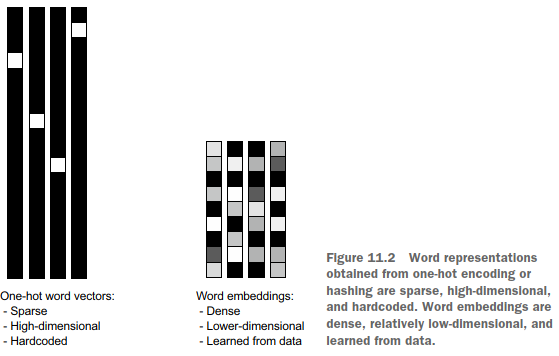



## Using pretrained Word Embeddings

In this assignment, we will use GloVe word embeddings which is precomputed on the 2014
English Wikipedia dataset. It’s an 822 MB zip file containing 100-dimensional embedding vectors for 400,000 words (or non-word tokens). You can download the word embedding file which contains embeddings for each word as the image below. After downloading the image, you can open and see the raw file before using it.

![](https://i1.wp.com/turbolab.in/wp-content/uploads/2021/12/glove.jpg?resize=500%2C358&ssl=1)

First I am extracting the pretrained embeddings `'glove.6B.100d.txt'`.

In [ ]:
# Download the dataset
import urllib.request
import zipfile

url = "http://nlp.stanford.edu/data/glove.6B.zip"
filename = "glove.6B.zip"

urllib.request.urlretrieve(url, filename)

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extract('glove.6B.100d.txt')

Then I read the embeddings into a dictionary.

In [10]:
path_to_glove_file = 'glove.6B.100d.txt'
embeddings_index = {}

i = 0
with open(path_to_glove_file, "+r") as file:
    for line in file:
        word = line.split(" ")[0]
        vector = " ".join(line.split(" ")[1:])
        embeddings_index[word] = np.fromstring(vector, sep=' ')

print(f"Fount {len(embeddings_index)} word vectors.")

Fount 400000 word vectors.


Visualizing two of the embeddings. 

In [5]:
import itertools as it

dict(it.islice(embeddings_index.items(), 2))

{'the': array([-0.038194, -0.24487 ,  0.72812 , -0.39961 ,  0.083172,  0.043953,
        -0.39141 ,  0.3344  , -0.57545 ,  0.087459,  0.28787 , -0.06731 ,
         0.30906 , -0.26384 , -0.13231 , -0.20757 ,  0.33395 , -0.33848 ,
        -0.31743 , -0.48336 ,  0.1464  , -0.37304 ,  0.34577 ,  0.052041,
         0.44946 , -0.46971 ,  0.02628 , -0.54155 , -0.15518 , -0.14107 ,
        -0.039722,  0.28277 ,  0.14393 ,  0.23464 , -0.31021 ,  0.086173,
         0.20397 ,  0.52624 ,  0.17164 , -0.082378, -0.71787 , -0.41531 ,
         0.20335 , -0.12763 ,  0.41367 ,  0.55187 ,  0.57908 , -0.33477 ,
        -0.36559 , -0.54857 , -0.062892,  0.26584 ,  0.30205 ,  0.99775 ,
        -0.80481 , -3.0243  ,  0.01254 , -0.36942 ,  2.2167  ,  0.72201 ,
        -0.24978 ,  0.92136 ,  0.034514,  0.46745 ,  1.1079  , -0.19358 ,
        -0.074575,  0.23353 , -0.052062, -0.22044 ,  0.057162, -0.15806 ,
        -0.30798 , -0.41625 ,  0.37972 ,  0.15006 , -0.53212 , -0.2055  ,
        -1.2526  ,  0.071624,  

Now I need to convert my words into embeddings. To save training time and computation, I am going to use  pretrained GloVe embeddings which already contain semantic meaning.

In [11]:
embedding_dim = 100
embedding_matrix = np.zeros(shape = (max_features, embedding_dim))
hits = misses = 0
word_index = imdb.get_word_index()

words_with_embeddings = list(embeddings_index.keys())
for word, index in word_index.items():
    if index >= max_features: continue 
    if word in words_with_embeddings:
        embedding_matrix[index] = embeddings_index[word]
        hits += 1

    else:
        misses += 1


print(f"Converted {hits} words ({misses} misses)")

Converted 19131 words (868 misses)


## Model

My model begins by processing the embeddings using the pretrained GloVe embeddings.

I then use two bidirectional GRU layers. GRUs are a simplified version of LSTMs since they combine input and forget gates into a single update gate which reduces parameters and computational load. Therefore, I decided to use GRUs instead of LSTMs to improve training speed without comprimising training accuracy. I randomly remove 50% of the layers using dropout to reduce overfitting.

Finally, for classification I use a single dense layer with a sigmoid activation which outputs a probability of the sentiment. 

In [83]:
## GRU? etc.

inputs = keras.Input(shape=(None,), dtype="int64")
embed = tf.keras.layers.Embedding(input_dim=max_features, output_dim=100, 
                weights=[embedding_matrix], mask_zero = True)(inputs)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.GRU(32, return_sequences = True))(embed)
x = tf.keras.layers.Bidirectional(layer = tf.keras.layers.GRU(32))(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, "sigmoid")(x)

pretrained_gru = tf.keras.Model(inputs, outputs)


print(pretrained_gru.summary())
pretrained_gru.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 100) │  2,000,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, None, 64)  │     25,728 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64)        │     18,816 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,044,609 (7.80 MB)

 Trainable params: 2,044,609 (7.80 MB)

 Non-trainable params: 0 (0.00 B)

None


# Experiments

Interestingly while training accuracy and loss improved during training, validation accuracy and loss degraded. Training accuracy increased from 0.96 to 1.0 while validation accuracy decreased from 0.83 to 0.80. Training loss decreased from 0.13 to 9.4779e-05 while validation loss increased from 0.46 to 1.88. This can point to overfitting as the model begins to fit the training data too closely. 

In [85]:

callbacks = [keras.callbacks.ModelCheckpoint(filepath="./pretrained_gru.keras", monitor = "val_accuracy",save_best_only=True)]

pretrained_gru_history = pretrained_gru.fit(x_train, y_train, epochs = 20, 
                validation_data=(x_valid, y_valid), callbacks=callbacks)



Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.9553 - loss: 0.1336 - val_accuracy: 0.8336 - val_loss: 0.4617
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.9837 - loss: 0.0558 - val_accuracy: 0.8286 - val_loss: 0.6622
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.9930 - loss: 0.0257 - val_accuracy: 0.8182 - val_loss: 0.8647
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.9969 - loss: 0.0116 - val_accuracy: 0.8142 - val_loss: 0.9311
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.9976 - loss: 0.0091 - val_accuracy: 0.8121 - val_loss: 1.0550
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.8157 - val_loss: 1.1426
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9986 - loss: 0.0051 - val_accuracy: 0.8150 - val_loss: 1.2418
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.9980 - loss: 0.0059 - 

As stated above, the training and validation performance diverged which points to overfitting. This is despite dropping out nodes. Despite this, I saved the best model based on the validation loss. Therefore, I don't need to retrain to get the model with the best model metrics. Also, a validation accuracy of 0.83 and loss of 0.46 (for the best model) is good so I will continue with this model.

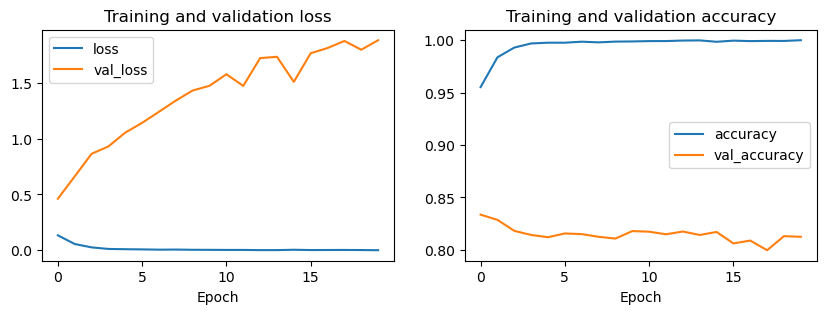

In [88]:
plot_learning(pretrained_gru_history)

Now I am going to see how well the model predicts the testing data after training. Cruically, this is not the best model. Just the final model after training.

In [176]:
pretrained_gru.evaluate(x_test, y_test)
predictions = pretrained_gru.predict(x_test)

391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8154 - loss: 1.8288
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


In [177]:
correct_preds = (len(y_test[((predictions > 0.5).astype(int).reshape(-1) == y_test)]) / len(y_test)) * 100

f"The final model predicted {round(correct_preds, 2)}% of samples correctly."

'The final model predicted 81.54% of samples correctly.'

Now I am going to load the best model and see how well that one predicts the testing data. 

In [5]:
best_model = keras.models.load_model("./pretrained_gru.keras")


In [14]:


best_model.evaluate(x_test, y_test)
predictions = best_model.predict(x_test)

391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8334 - loss: 0.4624
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


In [7]:
correct_preds = (len(y_test[((predictions > 0.5).astype(int).reshape(-1) == y_test)]) / len(y_test)) * 100

f"The best model classified {round(correct_preds, 2)}% of samples correctly."

'The best model classified 83.34% of samples correctly.'

Looking at the actual reviews I can begin to see why the model decided to classify reviews as either positive or negaitve. It is important to remember that I selected the 20000 most common words so even with that much variety, the reviews aren't going to be complete. 

In [ ]:
word_index = imdb.get_word_index()

def get_word_by(index):
    return list(filter(lambda x: word_index[x] == index, word_index))[0]

def vec_to_sentence(token_vec):
    s = ""
    for token in token_vec:
        if token == 0: continue ## padding tokens
        s += f" {get_word_by(token)}"
    return s



In [30]:
int_preds = (predictions > 0.5).astype(int).reshape(-1)
for i in range(3):
    actual_sent = pred_sent = "positive"
    if y_test[i] == 0: actual_sent = "negative"
    if int_preds[i] == 0: pred_sent = "negative"
    print(f"review {i+1}\n{vec_to_sentence(x_test[i])}")
    print(f"actual sentiment: {actual_sent}  |  predicted sentiment: {pred_sent}")
    print("-------------")

review 1
 the wonder own as by is sequence i i jars roses to of hollywood br of down shouting getting boring of ever it sadly sadly sadly i i was then does don't close faint after one carry as by are be favourites all family turn in does as three part in another some to be probably with world uncaring her an have faint beginning own as is sequence
actual sentiment: negative  |  predicted sentiment: negative
-------------
review 2
 of rukh br for cupboard expressing stunts black that story at actual in can as movie is strands has though songs and action it's action his one me and grass this second no all way and not lee warhol be moves br figure of you boss movie is snatched 9 br propaganda resumed and after at of smoke splendid snow saturday it's results this of load it's think class br think cop for games make southern things to it jolly who gladys if is boyfriend you which is tony by this make residents too not make above it even background
actual sentiment: positive  |  predicted se

# Conclusions

Overall, I was able to create a bideirectional GRU which uses pretrained GloVe embeddings which was able to classify reviews as being either positive or negative. I was able to determine that the 20,000 most common words were sufficent to be able to classify sentiment with an accuracy of 0.83. 

A challenge I faced was a degredation in validation accuracy and loss. Due to gradient descent, I already understood that it is possible to overshoot the energy minimum and experience training degredation. Also, overfitting can cause the model to learn the intricate patterns in the training data instead of the broad patterns which are generalizable to the validation and testing data. For these reasons, I decided to use `callbacks` to be able to save the best model based on the validation loss. Therefore, when the model started to overfit and validation performance degraded, I was still able to capture the best model use that on the testing data.

# References

Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011). Learning Word Vectors for Sentiment Analysis. In D. Lin, Y. Matsumoto, & R. Mihalcea (Eds.), Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies (pp. 142 8211 150). Association for Computational Linguistics. https://aclanthology.org/P11-1015/


# Grading

Your notebook is supposed to run well after downloading data to the working directory.

**Note: this is a WRITING assignment. Proper writing is REQUIRED. Comments are not considered as writing.**


Points | | Description
--|--|:--
5 | Introduction  
10 | Data Analysis |
20 | Word Embeddings |
20 | Pretrained Word Embeddings |
35 | RNN Model |
5 | Conclusions
5 | References